# **Arquitectura y Entrenamiento del modelo IDS basado en Deep Learning: Tabular ResNet**

Autor: Daniel Gomollón Embid

Trabajo Fin de Grado: Análisis, Explotación y Mitigación de Vulnerabilidades de Sistemas de Detección de intrusiones basados en Machine Learning

Fecha: 27/02/2026

**Universidad de Zaragoza**

------------------

Este cuaderno conforma la primera etapa de aproximación metodológica propuesta para el Trabajo de Fin de Grado. Siguiendo el principio de complejidad incremental, el objetivo de esta iteración es establecer una línea base de rendimiento de alto nivel frente a la cual se medirán las futuras incorporaciones (Autoencoder Variacional y Distancia de Mahalanobis).

## Fundamentos Arquitectónicos

La arquitectura propuesta en este experimento es una **Tabular ResNet** ampliada con dos técnicas (tendencia State Of The Art en investigación) para mitigar las debilidades matemáticas de las redes neuronales frente a datos de tráfico de red altamente desbalanceados:

1. **Squeeze-and-Excitation (S.E.) Blocks:** Mecanismo de atención que modela explícitamente las interdependencias entre las características (features) del tráfico (ej. duración del flujo vs. bytes transmitidos), aplicando una recalibración adaptativa de los pesos de la red.
2. **Spectral Normalization (SN):** Estabilizador matemático originalmente diseñado para Redes Generativas Antagónicas (GANs). Limita la constante de Lipschitz de las matrices de pesos, garantizando que los gradientes no exploten al procesar características con alta varianza o al intentar converger sobre clases hiper-minoritarias como el *Ransomware*, *Botnet* y diversos *Exploits*.

## 1. PREPARACIÓN DEL ENTORNO Y ACELERACIÓN HARDWARE

In [ ]:
import sys
import os

# Verificación de entorno Colab y montaje de unidades
try:
    from google.colab import drive
    drive.mount('/content/drive')

    # IMPORTANTE: Ajustar esta ruta a la ubicación exacta del repositorio en Drive
    PROJECT_PATH = '/content/drive/MyDrive/Codigo_TFG'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
    print(f"[-] Entorno Colab detectado. Directorio de trabajo: {os.getcwd()}")
except ImportError:
    print("[-] Entorno local detectado. Ejecutando sin Google Drive.")

import torch
print(f"[-] Motor PyTorch Versión: {torch.__version__}")

# Asignación de dispositivo (Device Agnostic Code)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[-] Dispositivo de cómputo asignado: {device}")

if device.type == 'cuda':
    print(f"    Hardware: {torch.cuda.get_device_name(0)}")
    print(f"    VRAM Disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Mounted at /content/drive
[-] Entorno Colab detectado. Directorio de trabajo: /content/drive/MyDrive/Codigo_TFG
[-] Motor PyTorch Versión: 2.10.0+cu128
[-] Dispositivo de cómputo asignado: cuda
    Hardware: Tesla T4
    VRAM Disponible: 15.64 GB


## **IMPORTANTE: Copiar los .npy a la RAM local de Colab**

In [ ]:
import shutil, os

LOCAL = '/content/data/processed/resultados_2_buffer'
os.makedirs(LOCAL, exist_ok=True)

for f in ['X_train.npy','y_train.npy','X_val.npy','y_val.npy','X_test.npy','y_test.npy']:
    shutil.copy(
        f'/content/drive/MyDrive/Codigo_TFG/data/processed/resultados_2_buffer/{f}',
        f'{LOCAL}/{f}'
    )
    print(f'Copiado: {f}')

Copiado: X_train.npy
Copiado: y_train.npy
Copiado: X_val.npy
Copiado: y_val.npy
Copiado: X_test.npy
Copiado: y_test.npy


## **Proceso de Optimización (Training Loop)**

El entrenamiento se ejecuta sobre el conjunto de datos de entrenamiento ($Train$), el cual fue previamente balanceado mediante submuestreo optimizado en la fase del pipeline ETL para alcanzar una proporción 60/40 (Benigno/Ataque).

Para combatir el sub-desbalance interno de las clases maliciosas, el optimizador minimiza una función de **Cross Entropy Loss** sumado a Class Weights para asegurar dinamicamente "castigos" proporcionales a ataques con pocas muestras (castigo/peso alto) respecto las grandes (castigo más ligero). A diferencia de la entropía cruzada estándar, la pérdida focal reduce dinámicamente el peso de los flujos de red que ya han sido clasificados correctamente con alta confianza, forzando a la red a concentrar sus gradientes en los ejemplos "difíciles" (ataques sutiles o novedosos).

## 2. ENTRENAMIENTO DEL MODELO

In [ ]:
from src.helpers import set_seed
from src.models.resnet.trainer import Trainer
from src.config import Config

# garantizar reproducibilidad en todos entrenamientos
set_seed(Config.SEED)

Config.DATA_PROCESSED_PATH = '/content/data/processed/resultados_2_buffer'
print(f"Datos desde: {Config.DATA_PROCESSED_PATH}")

print(f"[-] Iniciando entrenamiento de Tabular ResNet + "
      f"SwiGLU + Squeeze and Excitation + Spectral Normalization + "
      f"Learnable Skip Connections (Bloques: {Config.N_BLOCKS})")

# lanzar entrenamiento
history, model = Trainer().run(
    suffix        = "",
    resume        = False,
    epochs        = 50,    # Si la loss oscila mucho, bajar a 5e-4
    lr            = 1e-3,
    patience      = 10,
    dropout       = 0.1,  # Dropout troncal
    inner_dropout = 0.0,    # Cero para proteger gradientes
    hidden_dim    = 256,
    n_blocks      = 4,
    mixup_alpha   = 0.2,    # Data Augmentation
    use_class_weights  = False,
)

print("\n[-] Entrenamiento finalizado. Procediendo a evaluación métrica.")

[-] Semilla global fijada en 42 (Reproducibilidad Garantizada).
Datos desde: /content/data/processed/resultados_2_buffer
[-] Iniciando entrenamiento de Tabular ResNet + SwiGLU + Squeeze and Excitation + Spectral Normalization + Learnable Skip Connections (Bloques: 4)

ENTRENAMIENTO — TabularResNet  [Fase 1]
Device : cuda

[-] Historial de épocas se guardará en: training_log_3.txt

[-] 1. Cargando datos...
   Train : (1080844, 66)
   Val   : (199984, 66)
   Test  : (199985, 66)
   π_train = 0.3339

[-] 2. Construyendo modelo...
   Parámetros entrenables: 977,804

[-] 3. Calculando class weights...
   Clase 0 (Benign         ): weight = 0.5000
   Clase 1 (DoS            ): weight = 0.8669
   Clase 2 (DDoS           ): weight = 0.5000
   Clase 3 (Web/Injection  ): weight = 1.2017
   Clase 4 (Brute Force    ): weight = 1.4506
   Clase 5 (Recon          ): weight = 0.9126
   Clase 6 (Malware        ): weight = 0.9382
   Clase 7 (Exploits       ): weight = 2.1959

[-] 4. Entrenando desde epo

TabularResNet:   0%|          | 0/50 [00:00<?, ?epoch/s]

  Epoch 001/50:   0%|          | 0/4223 [00:00<?, ?batch/s]

Epoch 001/50 | T.Loss: 0.6765 | V.Loss: 0.5240 | F1: 0.9200 | AUC: 0.9967 | LR: 1.00e-03 | t=97s
   [✓] Mejor modelo guardado — epoch 1 (val F1=0.9200)


  Epoch 002/50:   0%|          | 0/4223 [00:00<?, ?batch/s]

...

Epoch 035/50 | T.Loss: 0.6024 | V.Loss: 0.5213 | F1: 0.9386 | AUC: 0.9873 | LR: 1.25e-04 | t=96s
   [EarlyStopping] sin mejora 8/10 (mejor: 0.9407)


  Epoch 036/50:   0%|          | 0/4223 [00:00<?, ?batch/s]

Epoch 036/50 | T.Loss: 0.5986 | V.Loss: 0.5210 | F1: 0.9391 | AUC: 0.9927 | LR: 1.25e-04 | t=97s
   [EarlyStopping] sin mejora 9/10 (mejor: 0.9407)


  Epoch 037/50:   0%|          | 0/4223 [00:00<?, ?batch/s]

Epoch 037/50 | T.Loss: 0.5981 | V.Loss: 0.5205 | F1: 0.9391 | AUC: 0.9881 | LR: 1.25e-04 | t=96s
   [EarlyStopping] sin mejora 10/10 (mejor: 0.9407)

[!] Early Stopping activado en epoch 37

   lr=0.001 | epochs=50 | patience=10
   dropout=0.1 | hidden=256 | blocks=4
   mixup_alpha=0.2

EVALUACIÓN FINAL — Test set
   Cargado: epoch 27 (val F1=0.9407)

--- Distribución laboratorio (sin corrección prior) ---
  Accuracy : 0.9914
  F1-macro : 0.9171
  AUC-ROC  : 0.9989

--- Distribución producción (corrección prior 95/5) ---
  Accuracy : 0.9959
  F1-macro : 0.9501
  AUC-ROC  : 0.9989

--- F1 por macro-clase (producción) ---
  0 Benign          0.9981 ███████████████████
  1 DoS             0.9835 ███████████████████
  2 DDoS            0.9893 ███████████████████
  3 Web/Injection   0.9925 ███████████████████
  4 Brute Force     0.9623 ███████████████████
  5 Recon           0.8650 █████████████████
  6 Malware         0.8811 █████████████████
  7 Exploits        0.9294 ██████████████████



## **Re-calibración del prior bayesiano con diferentes splits de distribución**
Con pi_train=0.3339
- 95/5
- 94/6
- 97/3
- 98/2
- 99/1

In [ ]:
import numpy as np
from src.evaluator import ModelEvaluator

# Cargar probabilidades crudas ya calculadas
probs_raw = np.load('outputs/models/test_probs.npy')  # las crudas, sin corrección
y_test    = np.load('data/processed/resultados_2_buffer/y_test.npy')
pi_train  = np.load('outputs/models/pi_train.npy')

# Tabla de sensibilidad al prior
priors = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]

print(f"{'π_prod':>8} | {'F1-macro':>10} | {'FPR':>8} | {'FNR':>8} | {'Attack Recall':>14}")
print("-" * 60)

for pi_prod in priors:
    evaluator = ModelEvaluator(pi_prod=pi_prod)
    result    = evaluator.evaluate(
        probs_raw, y_test,
        pi_train = pi_train,
        label    = f"pi={pi_prod}",
        verbose  = False,   # sin spam de output
    )
    print(f"{pi_prod:>8.2f} | {result.f1_macro:>10.4f} | "
          f"{result.fpr:>8.4f} | {result.fnr:>8.4f} | "
          f"{result.attack_recall:>14.4f}")

np.save('outputs/models/test_probs_raw_clean.npy', probs_raw)
print("\nGuardado en /outputs/models")

  π_prod |   F1-macro |      FPR |      FNR |  Attack Recall
------------------------------------------------------------
    0.01 |     0.8583 |   0.0003 |   0.1874 |         0.8126
    0.02 |     0.9445 |   0.0008 |   0.0635 |         0.9365
    0.05 |     0.9501 |   0.0016 |   0.0409 |         0.9591
    0.10 |     0.9449 |   0.0028 |   0.0317 |         0.9683
    0.15 |     0.9391 |   0.0039 |   0.0265 |         0.9735
    0.20 |     0.9335 |   0.0049 |   0.0225 |         0.9775

Guardado en /outputs/models


## **Guardar probabilidades para calibración de umbrales post-entrenamiento**

In [ ]:
# APUNTAR A RAIZ DEL PROYECTO PARA EJECUTAR EN LOCAL EL GRIDSEARCH DE THRESHOLD OPTIMIZER
import sys
import os

# apuntar al raíz del proyecto — ajusta esta ruta a donde tengas Codigo_TFG
PROJECT_PATH = r'G:\Mi unidad\Codigo_TFG'  # Windows
# PROJECT_PATH = '/home/usuario/Codigo_TFG'  # Linux/Mac

os.chdir(PROJECT_PATH)
sys.path.insert(0, PROJECT_PATH)

print(f"Directorio: {os.getcwd()}")
print(f"src existe: {os.path.isdir('src')}")

Directorio: G:\Mi unidad\Codigo_TFG
src existe: True


In [ ]:
# Necesario para ThresholdOptimizer — calibra en val, aplica en test sin GPU
import torch
import numpy as np
import os
from src.config import Config
from src.models.resnet.advanced_model import TabularResNet
from src.models.resnet.trainer import Trainer, evaluate

# ── reconstruir modelo desde checkpoint ───────────────────────
ck = torch.load("outputs/models/best_resnet.pt",
                map_location='cpu', weights_only=False)

model = TabularResNet(
    input_dim   = 61,
    num_classes = Config.NUM_CLASSES,
    hidden_dim  = 256,
    embed_dim   = Config.EMBED_DIM,
    n_blocks    = 4,
    dropout     = 0.1,
).to('cpu')

model.load_state_dict(ck['model'])
model.eval()
print(f"✓ Modelo cargado — epoch {ck['epoch']} | val F1={ck['val_f1']:.4f}")

# ── construir loaders ──────────────────────────────────────────
t = Trainer()
val_loader  = t._make_loader(
    np.load(f"{Config.DATA_PROCESSED_PATH}/X_val.npy"),
    np.load(f"{Config.DATA_PROCESSED_PATH}/y_val.npy"),
)
test_loader = t._make_loader(
    np.load(f"{Config.DATA_PROCESSED_PATH}/X_test.npy"),
    np.load(f"{Config.DATA_PROCESSED_PATH}/y_test.npy"),
)

# ── inferencia y guardado ──────────────────────────────────────
_, _, _, _, _, y_val_labels,  probs_val  = evaluate(model, val_loader,  'cpu')
_, _, _, _, _, y_test_labels, probs_test = evaluate(model, test_loader, 'cpu')

os.makedirs("outputs/models", exist_ok=True)
np.save("outputs/models/val_probs.npy",   probs_val)
np.save("outputs/models/val_labels.npy",  y_val_labels)
np.save("outputs/models/test_probs.npy",  probs_test)
np.save("outputs/models/test_labels.npy", y_test_labels)

print(f"[-] Guardado:")
print(f"    val_probs.npy  : {probs_val.shape}")
print(f"    test_probs.npy : {probs_test.shape}")

✓ Modelo cargado — epoch 13 | val F1=0.9318
[-] Guardado:
    val_probs.npy  : (199989, 8)
    test_probs.npy : (199992, 8)


## **Análisis de Convergencia**

La evaluación del rendimiento del modelo durante el entrenamiento no debe basarse en la métrica de Exactitud (*Accuracy*), dado que un modelo que prediga "Benigno" el 100% de las veces en el conjunto de Validación lograría un 75% de acierto engañoso.

Las métricas monitoreadas para activar el *Early Stopping* son la **Pérdida (Loss)** y el **F1-Macro**. Esta última pondera todas las clases por igual, independientemente de su soporte poblacional, asegurando que el modelo no sacrifique la detección de *Ransomware* para mejorar la detección de *DDoS*.

## 3. VISUALIZACIÓN DE CURVAS DE APRENDIZAJE

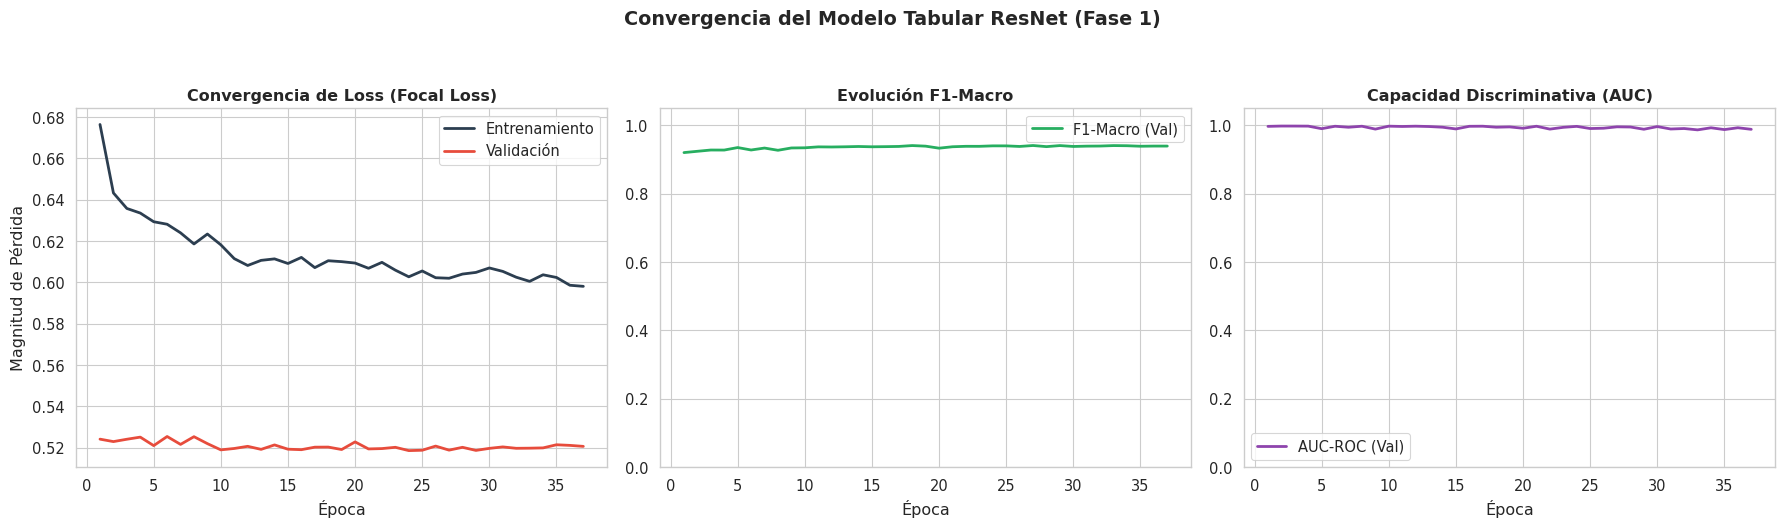

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual académica (homogénea con Notebook 01)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Convergencia del Modelo Tabular ResNet (Fase 1)', fontweight='bold', y=1.05)

epochs = range(1, len(history['train_loss']) + 1)

# Gráfica 1: Evolución de la Función de Pérdida
axes[0].plot(epochs, history['train_loss'], label='Entrenamiento', color='#2c3e50', linewidth=2)
axes[0].plot(epochs, history['val_loss'], label='Validación', color='#e74c3c', linewidth=2)
axes[0].set_title('Convergencia de Loss', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Magnitud de Pérdida')
axes[0].legend()

# Gráfica 2: F1-Macro (Métrica principal contra el desbalance)
axes[1].plot(epochs, history['val_f1'], label='F1-Macro (Val)', color='#27ae60', linewidth=2)
axes[1].set_title('Evolución F1-Macro', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylim([0, 1.05])
axes[1].legend()

# Gráfica 3: AUC-ROC (Discriminación global)
axes[2].plot(epochs, history['val_auc'], label='AUC-ROC (Val)', color='#8e44ad', linewidth=2)
axes[2].set_title('Capacidad Discriminativa (AUC)', fontweight='bold')
axes[2].set_xlabel('Época')
axes[2].set_ylim([0, 1.05])
axes[2].legend()

plt.tight_layout()
os.makedirs('outputs/logs', exist_ok=True)
plt.savefig('outputs/logs/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## **Evaluación Diagnóstica: Matriz de Confusión y Falsos Positivos**

La matriz de confusión evaluada sobre el conjunto de **Prueba (Test Set)** es la prueba de fuego del IDS. Dado que este conjunto presenta una distribución real (95% benigno, 5% ataque), un índice elevado de Falsos Positivos (flujos benignos clasificados como ataques) invalidaría la usabilidad comercial del sistema, generando lo que en ciberseguridad se conoce como *Fatiga de Alertas* (Alert Fatigue).

## 4. DIAGNÓSTICO MATRICIAL SOBRE CONJUNTO DE PRUEBA (MUNDO REAL)


[-] Evaluando matriz sobre 199,985 flujos de Prueba.


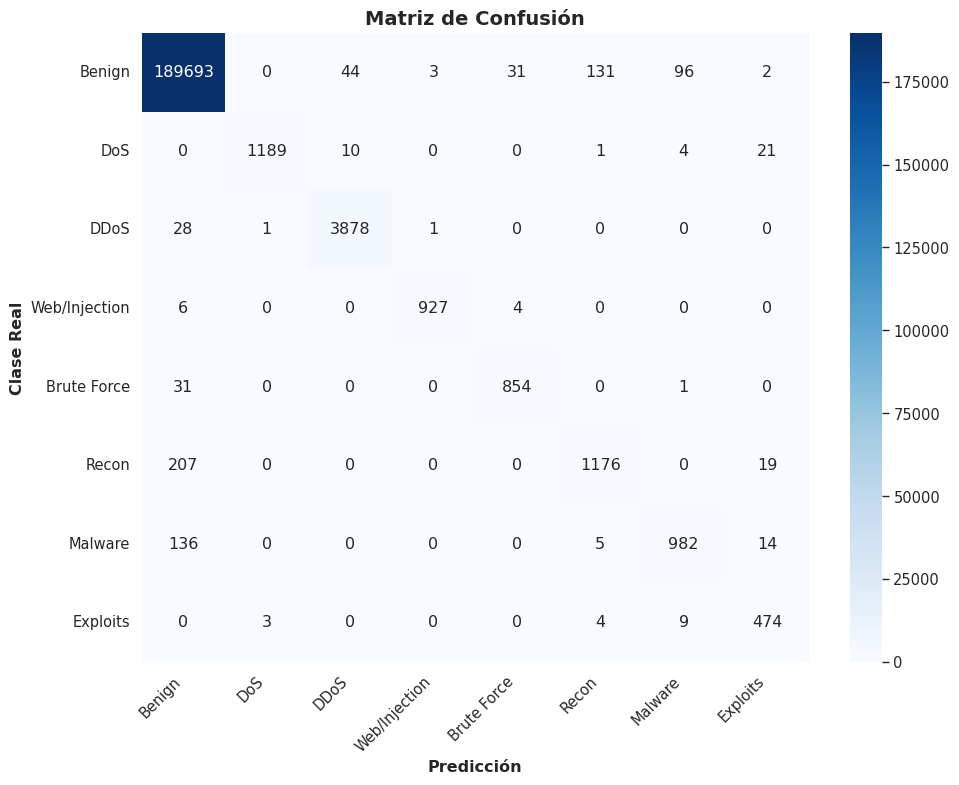

In [ ]:
from src.utils import plot_confusion_matrix

try:
    preds = np.load('outputs/models/test_preds.npy')
    labels = np.load('outputs/models/test_labels.npy')

    print(f"[-] Evaluando matriz sobre {len(labels):,} flujos de Prueba.")
    plot_confusion_matrix(labels, preds, Config.CLASS_NAMES)
except FileNotFoundError:
    print("[!] Error: No se encontraron las predicciones. Verifique el módulo Trainer.")

## **Capacidad de Detección en Entornos Asimétricos (Curvas PR)**

La métrica ROC-AUC es excesivamente optimista cuando la clase negativa (tráfico benigno) es aplastantemente mayoritaria. Por ello, el estándar de rigor académico exige reportar el Área Bajo la Curva de Precisión y Recuperación (PR-AUC).

Esta métrica responde a la pregunta operativa fundamental: *De todas las alertas que dispara el sistema para una categoría de ataque específica, ¿qué porcentaje representa amenazas reales?*

## 5. CURVAS DE PRECISIÓN Y EXHAUSTIVIDAD (PR-A) MULTICLASE

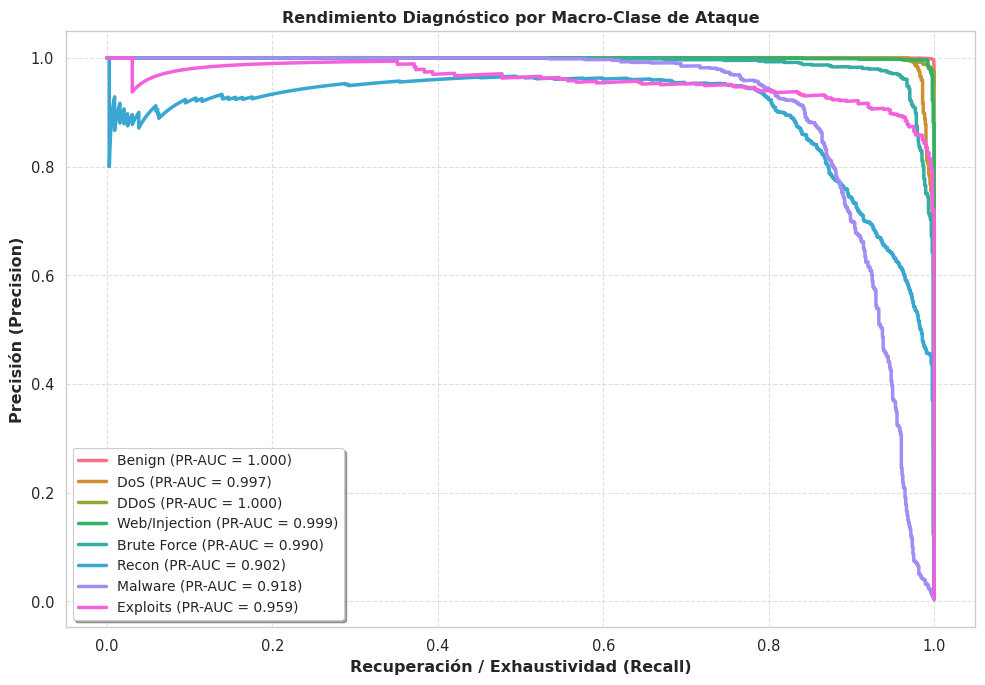

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

try:
    probs = np.load('outputs/models/test_probs.npy')
    labels = np.load('outputs/models/test_labels.npy')

    # Binarización One-vs-Rest para análisis multiclase
    labels_bin = label_binarize(labels, classes=list(range(Config.NUM_CLASSES)))

    plt.figure(figsize=(10, 7))
    colors = sns.color_palette("husl", Config.NUM_CLASSES)

    for i, (name, color) in enumerate(zip(Config.CLASS_NAMES, colors)):
        precision, recall, _ = precision_recall_curve(labels_bin[:, i], probs[:, i])
        pr_auc = auc(recall, precision)

        plt.plot(recall, precision, color=color, lw=2.5,
                 label=f'{name} (PR-AUC = {pr_auc:.3f})')

    plt.xlabel('Recuperación / Exhaustividad (Recall)', fontweight='bold')
    plt.ylabel('Precisión (Precision)', fontweight='bold')
    plt.title('Rendimiento Diagnóstico por Macro-Clase de Ataque', fontweight='bold')
    plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig('outputs/logs/pr_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print("[!] Error: Archivos de probabilidades no encontrados.")